<a href="https://colab.research.google.com/github/ahmade1358/python/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

اتصال به گوگل درایو

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


بارگذاری کتابخانه های موردنیاز

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE


بارگذاری فایل داده و نمایش اطلاعاتی در باره ان

In [4]:
try:
    df = pd.read_csv("//content/drive/MyDrive/project/hds.csv")
    print("فایل با موفقیت بارگذاری شد")
except FileNotFoundError:
    print("فایل پیدا نشد")

copydf = df.copy()
print(df.head())
print(df.info())

فایل با موفقیت بارگذاری شد
      id  gender   age  hypertension  heart_disease ever_married work_type  \
0  47350  Female  0.08             0              0           No  children   
1  29955    Male  0.08             0              0           No  children   
2  22877    Male  0.16             0              0           No  children   
3  41500    Male  0.16             0              0           No  children   
4   8247    Male  0.16             0              0           No  children   

  Residence_type  avg_glucose_level   bmi smoking_status  stroke  
0          Urban             139.67  14.1        Unknown       0  
1          Rural              70.33  16.9        Unknown       0  
2          Urban             114.71  17.4        Unknown       0  
3          Rural              69.79  13.0        Unknown       0  
4          Urban             109.52  13.9        Unknown       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 colum

حذف فیلد id

In [5]:
df = df.drop('id', axis=1)
print("فیلد id حذف شد")
print(df.info())


فیلد id حذف شد
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB
None


بررس فیلد bmi و حذف مقادیر پرت

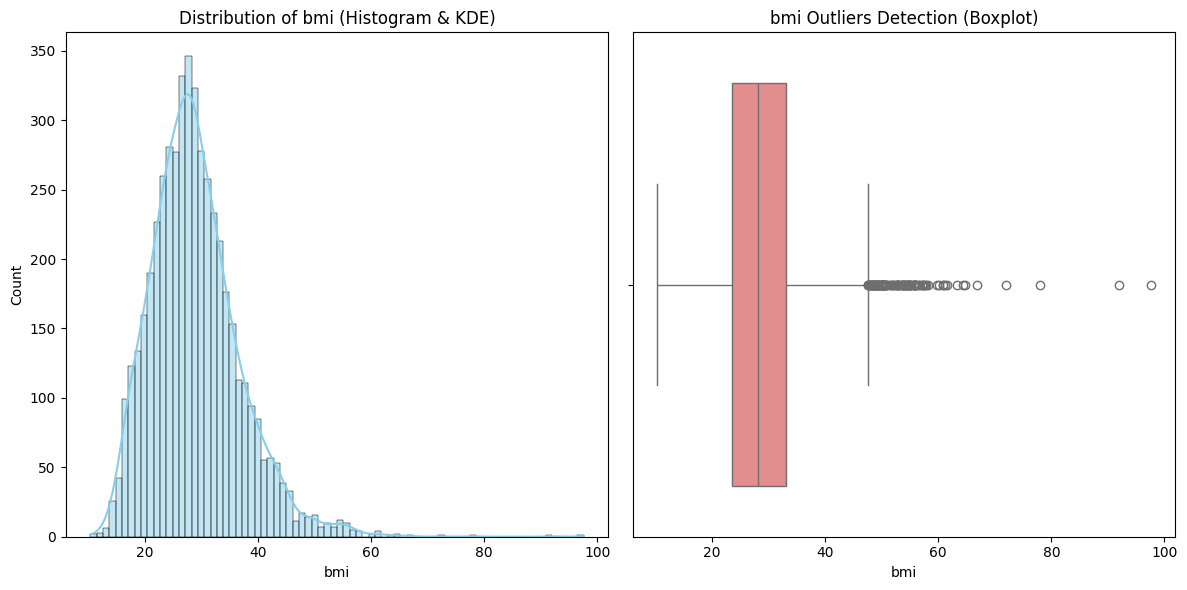

Statistical Summary of bmi:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64


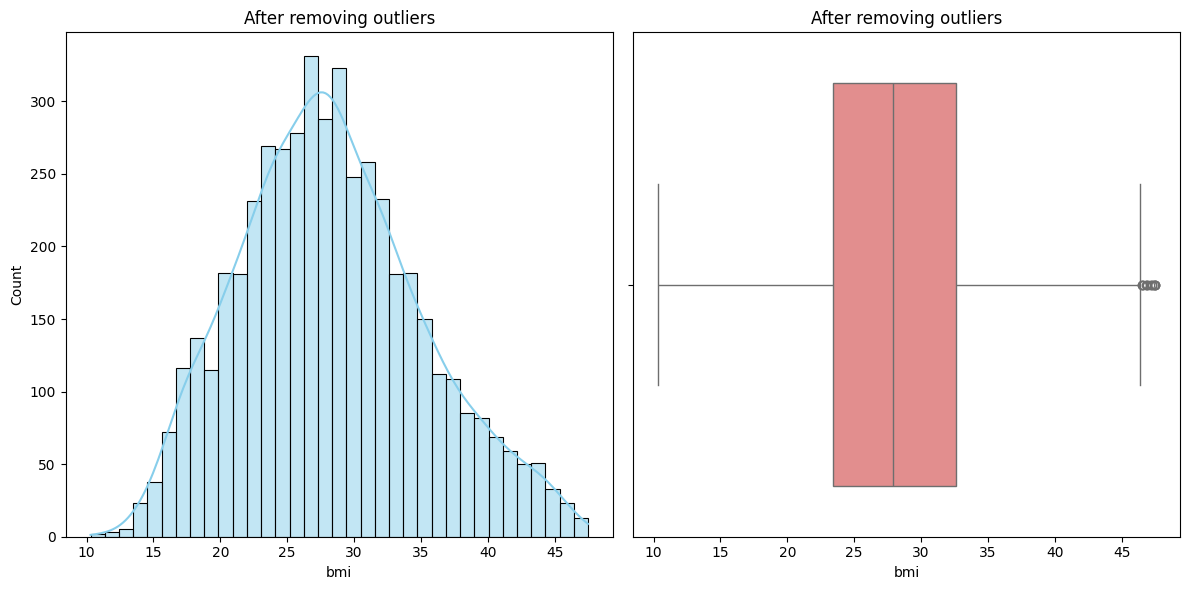

count    4799.000000
mean       28.313586
std         6.841250
min        10.300000
25%        23.400000
50%        27.900000
75%        32.600000
max        47.500000
Name: bmi, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(df['bmi'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of bmi (Histogram & KDE)')
sns.boxplot(x=df['bmi'], color='lightcoral', ax=axes[1])
axes[1].set_title('bmi Outliers Detection (Boxplot)')
plt.tight_layout()
plt.show()

print("Statistical Summary of bmi:")
print(df['bmi'].describe())

# حذف پرت‌ها با IQR
status = df['bmi'].describe()
q1 = status['25%']
q3 = status['75%']
iqr = q3 - q1
ml = q1 - 1.5 * iqr
mh = q3 + 1.5 * iqr
df.loc[(df['bmi'] < ml) | (df['bmi'] > mh), 'bmi'] = np.nan
df.dropna(subset=['bmi'], inplace=True)

# نمودار بعد از حذف پرت
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(df['bmi'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('After removing outliers')
sns.boxplot(x=df['bmi'], color='lightcoral', ax=axes[1])
axes[1].set_title('After removing outliers')
plt.tight_layout()
plt.show()
print(df['bmi'].describe())

بررس فیلد avg_glucose_level

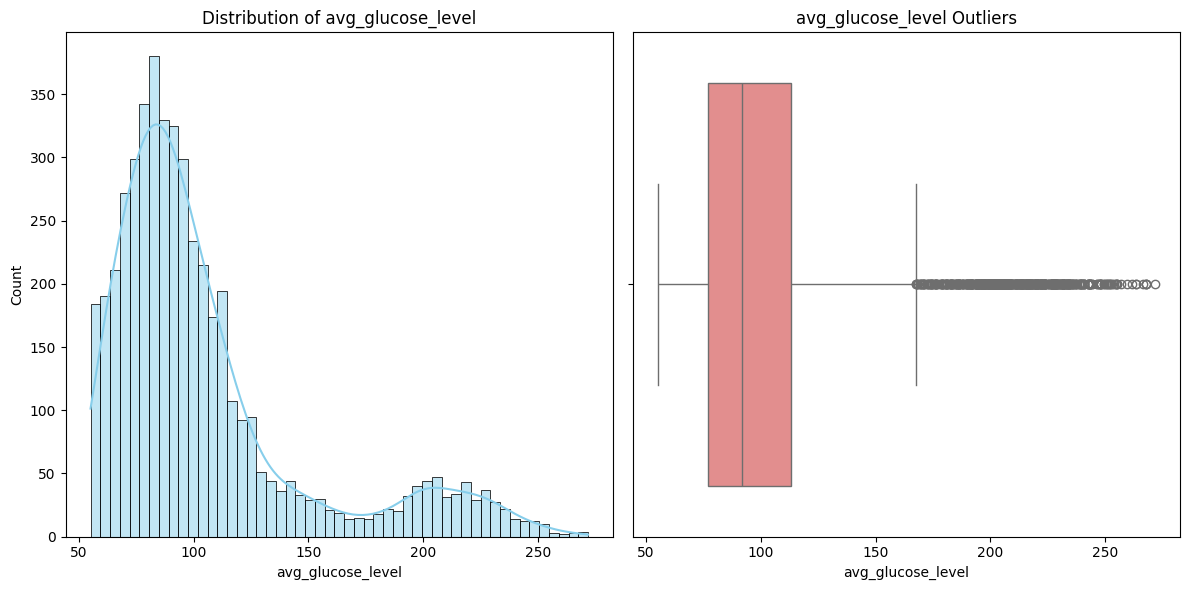

count    4799.000000
mean      104.968956
std        44.039454
min        55.120000
25%        77.040000
50%        91.650000
75%       113.245000
max       271.740000
Name: avg_glucose_level, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(df['avg_glucose_level'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of avg_glucose_level')
sns.boxplot(x=df['avg_glucose_level'], color='lightcoral', ax=axes[1])
axes[1].set_title('avg_glucose_level Outliers')
plt.tight_layout()
plt.show()
print(df['avg_glucose_level'].describe())
#مقادیر پرت را حذف نمی کنیم چون برای بیمار دیابتی این مقادیر طبیعی هستند

جایگزینی smoking_status با مد

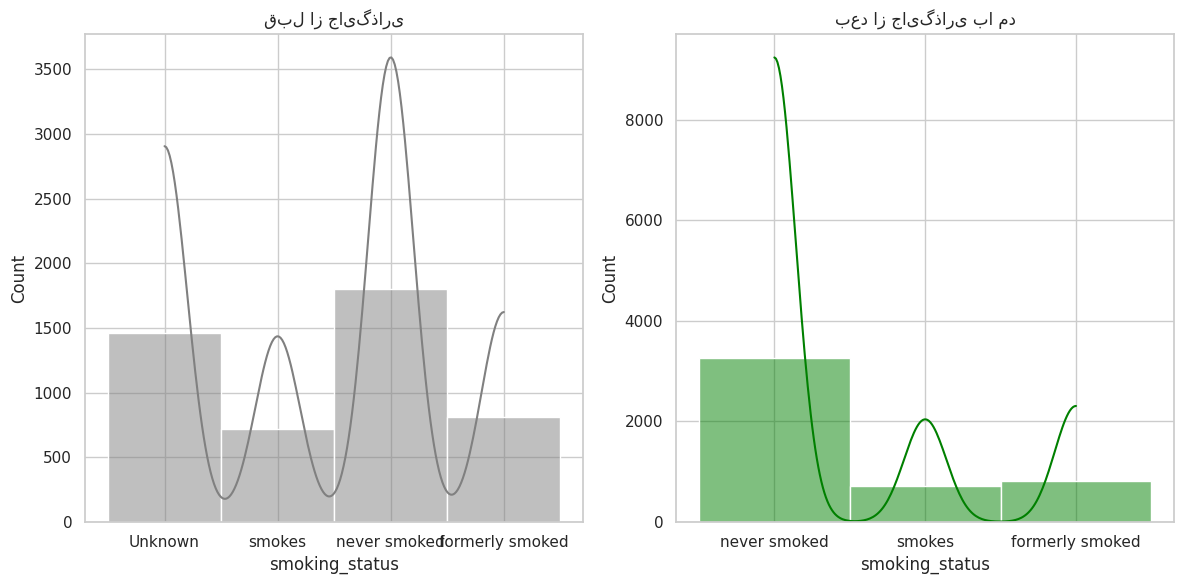

In [8]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(df['smoking_status'], kde=True, ax=axes[0], color='gray')
axes[0].set_title('قبل از جایگذاری')

df['smoking_status'] = df['smoking_status'].replace(['Unknown'], np.nan)
df['smoking_status'] = df['smoking_status'].fillna(df['smoking_status'].mode()[0])

sns.histplot(df['smoking_status'], kde=True, ax=axes[1], color='green')
axes[1].set_title('بعد از جایگذاری با مد')
plt.tight_layout()
plt.show()

آماده‌سازی  کدگذاری، تقسیم داده، اسکیل، KNNImputer و SMOTE

تعداد نمونه‌ها در هر کلاس:
stroke
0    4592
1     207
Name: count, dtype: int64

درصد هر کلاس:
stroke
0    95.686601
1     4.313399
Name: proportion, dtype: float64


/tmp/ipykernel_1027/2092298556.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


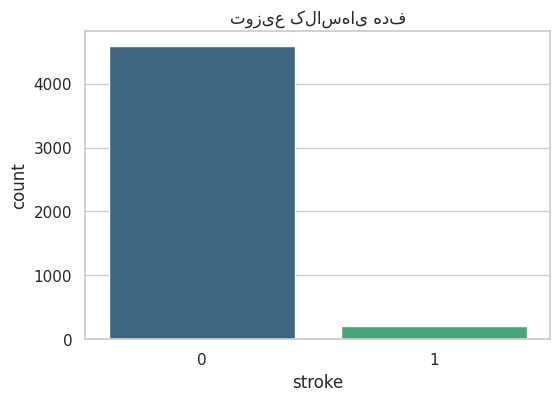

تعداد کلاس 1 قبل از SMOTE: 166
تعداد کلاس 1 بعد از SMOTE: 3673


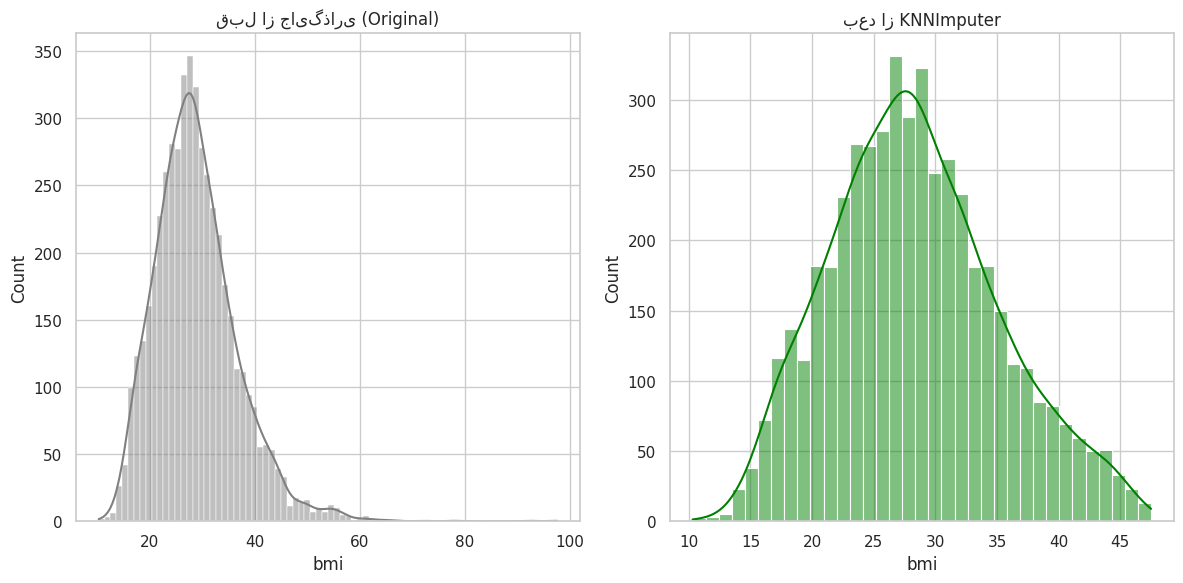

In [9]:
X = df.drop('stroke', axis=1)
y = df['stroke']

print("تعداد نمونه‌ها در هر کلاس:")
print(df['stroke'].value_counts())
print("\nدرصد هر کلاس:")
print(df['stroke'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('توزیع کلاس‌های هدف')
plt.show()

# کدگذاری متغیرهای دسته‌ای
scol = X.select_dtypes(include=['object']).columns.tolist()
for col in scol:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
    else:
        dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
        X = pd.concat([X, dummies], axis=1)
        X.drop(col, axis=1, inplace=True)

# تقسیم داده
numcol = ['age', 'avg_glucose_level', 'bmi']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)

# StandardScaler
scaler = StandardScaler()
X_train[numcol] = scaler.fit_transform(X_train[numcol])
X_test[numcol] = scaler.transform(X_test[numcol])

# KNNImputer برای مقادیر گمشده (در صورت وجود)
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# SMOTE برای متوازن‌سازی کلاس‌ها
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"تعداد کلاس 1 قبل از SMOTE: {sum(y_train == 1)}")
print(f"تعداد کلاس 1 بعد از SMOTE: {sum(y_train_res == 1)}")

# نمایش توزیع BMI بعد از KNNImputer (اختیاری)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(copydf['bmi'], kde=True, ax=axes[0], color='gray')
axes[0].set_title('قبل از جایگذاری (Original)')
sns.histplot(X['bmi'], kde=True, ax=axes[1], color='green')
axes[1].set_title('بعد از KNNImputer')
plt.tight_layout()
plt.show()